# US Crude Oil & Distillate — Supply/Demand Balance Model

A weekly S/D balance sheet for the US crude oil and distillate (diesel / heating oil) markets, built on EIA *Weekly Petroleum Status Report* data. It works like a financial balance sheet for physical oil: track what is produced, imported, exported and consumed each week, and whether the imbalance is building or draining inventories.

**Core insight:** when supply and demand fall out of balance, prices have to move to correct it. Model the imbalance before the market fully prices it in and you have a tradeable view.

**How to run:** paste a free EIA API key ([eia.gov/opendata](https://www.eia.gov/opendata)) into `EIA_API_KEY` in the config cell — or set the `EIA_API_KEY` environment variable — then *Run All*. With no key, the notebook runs end-to-end on a bundled **synthetic sample dataset** calibrated to realistic market levels, and every output is stamped accordingly.

| Phase | Section | Deliverable |
|---|---|---|
| 1 | Data + inventory charts | 10+ years of weekly data; level vs 5-yr seasonal average |
| 2 | Balance sheet | implied vs actual stock change, adjustment diagnostic |
| 3 | Seasonal analysis | surplus / deficit vs 5-yr norm — the core signal |
| 4 | Projection + scenarios | 12-week forward view, what-if tool |
| 5 | Market view | explicit written view + one-page PDF |

In [1]:
# ── Core imports & display settings ─────────────────────────────────────────
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10,
})

/Users/rileyadam/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 0 · Configuration

Set the API key, history depth and projection horizon here.

**Units convention** — the single most common data error in this dataset: flows are **Mb/d** (thousand barrels *per day*), inventory levels are **Mb** (thousand barrels, total). Converting a weekly flow imbalance into a stock change means multiplying by **7**.

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
from pathlib import Path
if Path(".env").exists():
    for line in Path(".env").read_text().splitlines():
        if "=" in line and not line.startswith("#"):
            k, v = line.split("=", 1)
            os.environ.setdefault(k.strip(), v.strip())
EIA_API_KEY   = os.environ.get("EIA_API_KEY", "YOUR_EIA_API_KEY_HERE")  # free key: eia.gov/opendata
START_DATE    = "2015-01-01"   # 10+ years of history (set earlier for more depth)
HORIZON_WEEKS = 12             # forward projection length (spec: 8-12 weeks)

DATA_DIR   = Path("data");   DATA_DIR.mkdir(exist_ok=True)
CHART_DIR  = Path("charts"); CHART_DIR.mkdir(exist_ok=True)
LIVE_CACHE = DATA_DIR / "eia_live_cache.csv"
SAMPLE_CSV = DATA_DIR / "sample_weekly_data.csv"
ONEPAGER   = Path("weekly_market_view.pdf")

DATA_MODE = "UNSET"  # set by load_data(): LIVE / CACHED / SAMPLE

# UNIT CONVENTION (the #1 data trap):
#   flows  = Mb/d  (thousand barrels per day)
#   stocks = Mb    (thousand barrels, total level)
#   weekly stock change implied by flows = (supply - demand) * 7
MBD, MB = "Mb/d", "Mb"

## 1 · The balance-sheet framework

Everything hangs off one identity:

$$\text{Supply} - \text{Demand} = \Delta\,\text{Inventory}$$

Eleven weekly EIA series cover it — six for crude, five for distillate — each tagged with its role in the identity. Choices worth noting: crude stocks are **commercial, excluding the SPR** (`WCESTUS1`), because SPR moves are policy rather than market; imports and exports are kept **gross** on opposite sides of the balance rather than netted; refinery demand is **net crude input in Mb/d** (a volume, not the utilization percentage); and *product supplied* is EIA's demand **proxy** — it measures disappearance from primary storage, not metered final consumption. Cushing is a sub-component of total crude stocks (the WTI futures delivery point) and is tracked as a level indicator, not a separate balance line.

In [3]:
# ── Series catalog: the balance-sheet framework ──────────────────────────────
# role = how the series enters the S/D identity:   Supply − Demand = ΔInventory
SERIES = {
    # ---- crude (6 series) ----
    "WCRFPUS2":              dict(short="c_prod", commodity="crude", role="supply",  unit="Mb/d",
                                  name="US crude oil field production"),
    "WCEIMUS2":              dict(short="c_imp",  commodity="crude", role="supply",  unit="Mb/d",
                                  name="Crude oil imports (gross)"),
    "WCREXUS2":              dict(short="c_exp",  commodity="crude", role="demand",  unit="Mb/d",
                                  name="Crude oil exports"),
    "WCRRIUS2":              dict(short="runs",   commodity="crude", role="demand",  unit="Mb/d",
                                  name="Refiner net input of crude (refinery runs)"),
    "WCESTUS1":              dict(short="c_stk",  commodity="crude", role="level",   unit="Mb",
                                  name="Commercial crude stocks (EXCLUDING SPR)"),
    "W_EPC0_SAX_YCUOK_MBBL": dict(short="cush",   commodity="crude", role="level*",  unit="Mb",
                                  name="Cushing, OK crude stocks (sub-component)"),
    # ---- distillate (5 series) ----
    "WDIRPUS2":              dict(short="d_prod", commodity="distillate", role="supply", unit="Mb/d",
                                  name="Distillate production (refiner + blender net)"),
    "WDIIMUS2":              dict(short="d_imp",  commodity="distillate", role="supply", unit="Mb/d",
                                  name="Distillate imports"),
    "WDIEXUS2":              dict(short="d_exp",  commodity="distillate", role="demand", unit="Mb/d",
                                  name="Distillate exports"),
    "WDIUPUS2":              dict(short="d_dem",  commodity="distillate", role="demand", unit="Mb/d",
                                  name="Distillate product supplied (demand proxy)"),
    "WDISTUS1":              dict(short="d_stk",  commodity="distillate", role="level",  unit="Mb",
                                  name="Distillate stocks (total US)"),
}
SHORT = {sid: m["short"] for sid, m in SERIES.items()}

framework = (pd.DataFrame(SERIES).T
             .reset_index().rename(columns={"index": "eia_series_id"})
             [["commodity", "eia_series_id", "short", "name", "role", "unit"]]
             .sort_values(["commodity", "role"], ascending=[True, False])
             .reset_index(drop=True))
framework

,commodity,eia_series_id,short,name,role,unit
0,crude,WCRFPUS2,c_prod,US crude oil field production,supply,Mb/d
1,crude,WCEIMUS2,c_imp,Crude oil imports (gross),supply,Mb/d
2,crude,W_EPC0_SAX_YCUOK_MBBL,cush,"Cushing, OK crude stocks (sub-component)",level*,Mb
3,crude,WCESTUS1,c_stk,Commercial crude stocks (EXCLUDING SPR),level,Mb
4,crude,WCREXUS2,c_exp,Crude oil exports,demand,Mb/d
5,crude,WCRRIUS2,runs,Refiner net input of crude (refinery runs),demand,Mb/d
6,distillate,WDIRPUS2,d_prod,Distillate production (refiner + blender net),supply,Mb/d
7,distillate,WDIIMUS2,d_imp,Distillate imports,supply,Mb/d
8,distillate,WDISTUS1,d_stk,Distillate stocks (total US),level,Mb
9,distillate,WDIEXUS2,d_exp,Distillate exports,demand,Mb/d


## 2 · Data layer

Three tiers, tried in order: **live** EIA API v2 pull (needs a key) → **cached** copy of the last live pull → **bundled synthetic sample**, generated by the cell below and clearly labelled on every output. The sample is calibrated to realistic levels — the shale production ramp, the 2020 COVID shock, post-2023 export growth, and the tight mid-2026 market — so the full analytical pipeline can be demonstrated without credentials. Its stock levels carry seasonal texture derived from the generated flows, so Phase 2's reconciliation check behaves like real data.

EIA releases the Weekly Petroleum Status Report **every Wednesday at 10:30am ET**. Re-running this notebook after the release refreshes everything, including the one-page PDF at the end.

In [4]:
# ── Live data layer: EIA Open Data API v2 ────────────────────────────────────
EIA_URL = "https://api.eia.gov/v2/seriesid/{sid}"

def fetch_eia_series(sid: str, api_key: str, start: str = None) -> pd.Series:
    """Pull one weekly series via the EIA v2 API ('seriesid' compatibility route).
    IMPORTANT: this route needs the FULL v1 series identifier -- category prefix
    plus frequency suffix, e.g. 'PET.WCRFPUS2.W' -- not the bare code. All 11
    series in this project are weekly ('.W') under the petroleum category ('PET.').
    Weekly history is < 5,000 rows even from the 1980s, so one request suffices."""
    full_id = sid if "." in sid else f"PET.{sid}.W"
    params = {"api_key": api_key, "length": 5000}
    if start:
        params["start"] = start
    r = requests.get(EIA_URL.format(sid=full_id), params=params, timeout=30)
    r.raise_for_status()
    rows = r.json()["response"]["data"]
    s = (pd.DataFrame(rows)
         .assign(period=lambda x: pd.to_datetime(x["period"]))
         .set_index("period")["value"].astype(float).sort_index())
    s.name = sid
    return s

def fetch_all(api_key: str, start: str) -> pd.DataFrame:
    out = {}
    for sid in SERIES:
        out[sid] = fetch_eia_series(sid, api_key, start)
        print(f"  pulled {sid:<22} {len(out[sid]):>5} obs   latest {out[sid].index[-1].date()}")
    return pd.DataFrame(out).sort_index()

In [5]:
# ── Sample-data generator (fallback when no API key is configured) ───────────
# Produces SYNTHETIC weekly data, calibrated to realistic US market levels:
# the shale production ramp, the 2020 COVID demand shock, post-2023 export
# growth, seasonal refinery runs, and the tight 2026 market (crude ~412 Mb /
# ~7% below the 5-yr average, distillate ~106 Mb / ~10% below, Cushing ~19 Mb
# as of the late-June 2026 prints). Stocks are INTEGRATED from the generated
# flows plus a small mean-reverting "adjustment" term, so the Phase-2 balance
# check behaves like real EIA data (small, noisy reconciliation residual).
RNG = np.random.default_rng(42)

def _epoch(x) -> np.ndarray:
    return np.asarray(pd.to_datetime(x), dtype="datetime64[ns]").astype("int64").astype(float)

def _interp(dates, anchors) -> np.ndarray:
    """Piecewise-linear path through (date, value) anchor points."""
    t = _epoch([a for a, _ in anchors])
    v = np.asarray([b for _, b in anchors], dtype=float)
    return np.interp(_epoch(dates), t, v)

def _ar1(n, sd, rho=0.8) -> np.ndarray:
    e = np.zeros(n)
    for i in range(1, n):
        e[i] = rho * e[i - 1] + RNG.normal(0.0, sd)
    return e

def _seas(doy, amp, peak_doy) -> np.ndarray:
    return amp * np.cos(2 * np.pi * (doy - peak_doy) / 365.25)

def _flow(dates, anchors, sd, seas_amp=0.0, peak=200, floor=0.0, extra_seas=None):
    doy = dates.dayofyear.to_numpy(dtype=float)
    x = _interp(dates, anchors) + _seas(doy, seas_amp, peak) + _ar1(len(dates), sd)
    if extra_seas is not None:
        x = x + extra_seas(doy)
    return np.maximum(x, floor)

def _stocks(dates, implied_wk, anchors, noise_sd, rho=0.92, low_win=27,
            tex_scale=0.7, taper_wks=8):
    """Stock path = anchor path + flow-derived seasonal texture + OU noise.
    Texture is the high-frequency part of the cumulative flow-implied change,
    tapered to zero at the sample edges so the series lands on the anchors.
    Phase 2 then recovers the residual as a realistic, slowly-varying
    'adjustment' line -- mirroring how real EIA data reconciles surveyed
    flows against surveyed stock levels."""
    target = _interp(dates, anchors)
    n = len(dates)
    cum = np.cumsum(implied_wk)
    low = pd.Series(cum).rolling(low_win, center=True, min_periods=1).mean().to_numpy()
    tex = (cum - low) * tex_scale
    noise = np.zeros(n)
    for i in range(1, n):
        noise[i] = rho * noise[i - 1] + RNG.normal(0.0, noise_sd)
    taper = np.ones(n)
    taper[:taper_wks] = np.linspace(0.0, 1.0, taper_wks)
    taper[-taper_wks:] = np.linspace(1.0, 0.0, taper_wks)
    return target + (tex + noise) * taper

def generate_sample_data(end="2026-06-26") -> pd.DataFrame:
    idx = pd.date_range(start="2015-01-02", end=end, freq="W-FRI")

    # ---------------- crude flows (Mb/d) ----------------
    c_prod = _flow(idx, [("2015-01-02", 9.2), ("2015-06-05", 9.6), ("2016-01-01", 9.2),
        ("2016-09-02", 8.5), ("2017-06-02", 9.3), ("2018-01-05", 9.9), ("2018-12-07", 11.7),
        ("2019-12-06", 12.9), ("2020-03-13", 13.0), ("2020-05-15", 10.5), ("2020-08-07", 10.9),
        ("2021-02-19", 9.8), ("2021-06-04", 11.2), ("2021-12-03", 11.7), ("2022-12-02", 12.1),
        ("2023-10-06", 13.2), ("2024-06-07", 13.2), ("2024-12-06", 13.5), ("2025-06-06", 13.4),
        ("2025-12-26", 13.85), ("2026-06-26", 13.75)], sd=0.06)

    c_imp = _flow(idx, [("2015-01-02", 7.4), ("2016-06-03", 7.9), ("2017-06-02", 8.0),
        ("2018-06-01", 7.8), ("2019-06-07", 6.9), ("2020-06-05", 6.2), ("2021-06-04", 6.2),
        ("2022-06-03", 6.4), ("2023-06-02", 6.9), ("2024-06-07", 6.7), ("2025-06-06", 6.5),
        ("2026-01-02", 6.15), ("2026-05-01", 5.9), ("2026-06-26", 5.6)],
        sd=0.22, seas_amp=0.15, peak=190)

    c_exp = _flow(idx, [("2015-01-02", 0.45), ("2016-01-01", 0.55), ("2017-01-06", 0.8),
        ("2018-01-05", 1.4), ("2018-07-06", 2.0), ("2019-07-05", 2.9), ("2020-07-03", 3.2),
        ("2021-07-02", 3.0), ("2022-07-01", 3.5), ("2023-01-06", 3.9), ("2023-12-01", 4.1),
        ("2024-07-05", 3.95), ("2025-07-04", 3.85), ("2026-01-02", 4.15), ("2026-04-03", 4.4),
        ("2026-05-29", 4.35), ("2026-06-26", 3.6)], sd=0.30, floor=0.1)

    # refinery runs: summer peak, spring/autumn maintenance troughs
    runs_shape = lambda dd: (0.5 * np.cos(2 * np.pi * (dd - 205) / 365.25)
                             + 0.25 * np.cos(4 * np.pi * (dd - 15) / 365.25))
    runs = _flow(idx, [("2015-01-02", 15.95), ("2016-06-03", 16.15), ("2017-06-02", 16.55),
        ("2018-06-01", 16.75), ("2019-06-07", 16.55), ("2020-01-17", 16.2), ("2020-04-24", 12.9),
        ("2020-07-03", 14.1), ("2020-12-04", 13.9), ("2021-06-04", 15.6), ("2022-06-03", 15.95),
        ("2023-06-02", 15.8), ("2024-06-07", 15.95), ("2025-06-06", 15.9), ("2025-12-26", 16.1),
        ("2026-03-27", 16.25), ("2026-06-26", 16.45)], sd=0.15, extra_seas=runs_shape)

    # ---------------- distillate flows (Mb/d) ----------------
    d_prod = _flow(idx, [("2015-01-02", 4.95), ("2016-06-03", 4.85), ("2017-06-02", 5.05),
        ("2018-06-01", 5.1), ("2019-06-07", 5.1), ("2020-04-24", 4.55), ("2021-06-04", 4.65),
        ("2022-06-03", 4.95), ("2023-06-02", 4.8), ("2024-06-07", 4.85), ("2025-06-06", 4.95),
        ("2026-01-02", 5.0), ("2026-06-26", 5.3)], sd=0.09, seas_amp=0.12, peak=350)

    d_dem = _flow(idx, [("2015-01-02", 4.15), ("2016-06-03", 4.05), ("2017-06-02", 4.15),
        ("2018-06-01", 4.25), ("2019-06-07", 4.15), ("2020-04-24", 3.45), ("2020-12-04", 3.95),
        ("2021-06-04", 4.1), ("2022-06-03", 4.0), ("2023-06-02", 3.95), ("2024-06-07", 3.85),
        ("2025-06-06", 3.85), ("2026-01-02", 3.78), ("2026-06-26", 3.88)],
        sd=0.16, seas_amp=0.28, peak=15)

    d_exp = _flow(idx, [("2015-01-02", 1.1), ("2017-06-02", 1.3), ("2019-06-07", 1.35),
        ("2020-06-05", 1.2), ("2021-06-04", 1.05), ("2022-06-03", 1.25), ("2023-06-02", 1.15),
        ("2024-06-07", 1.2), ("2025-06-06", 1.28), ("2026-06-26", 1.32)], sd=0.13, floor=0.5)

    d_imp = _flow(idx, [("2015-01-02", 0.38), ("2018-01-05", 0.33), ("2020-01-03", 0.32),
        ("2022-01-07", 0.27), ("2024-01-05", 0.24), ("2026-06-26", 0.23)],
        sd=0.055, seas_amp=0.10, peak=20, floor=0.02)

    # ---------------- stocks (Mb): integrated from the flows ----------------
    c_impl = (c_prod + c_imp - runs - c_exp) * 7.0
    c_stk = _stocks(idx, c_impl, [("2015-01-02", 385), ("2015-05-01", 480), ("2016-05-06", 540),
        ("2016-12-02", 486), ("2017-03-31", 533), ("2017-12-29", 424), ("2018-09-21", 396),
        ("2019-06-07", 483), ("2020-01-03", 431), ("2020-06-19", 540), ("2021-06-04", 452),
        ("2022-06-03", 416), ("2023-03-10", 478), ("2023-12-01", 443), ("2024-06-07", 455),
        ("2024-12-06", 421), ("2025-02-28", 438), ("2025-06-06", 436), ("2025-09-05", 424),
        ("2025-12-26", 442), ("2026-02-27", 451), ("2026-04-10", 447), ("2026-05-01", 443),
        ("2026-05-29", 433.7), ("2026-06-05", 426.5), ("2026-06-12", 418.2),
        ("2026-06-19", 412.1), ("2026-06-26", 409.0)], noise_sd=0.78)

    d_impl = (d_prod + d_imp - d_dem - d_exp) * 7.0
    d_stk = _stocks(idx, d_impl, [("2015-01-02", 137), ("2016-01-15", 162), ("2016-08-05", 153),
        ("2017-10-06", 134), ("2018-10-05", 126), ("2019-07-05", 136), ("2020-08-07", 177),
        ("2021-07-02", 138), ("2022-05-06", 104), ("2022-11-04", 107), ("2023-07-07", 117),
        ("2024-02-02", 127), ("2024-07-05", 124), ("2025-02-07", 118), ("2025-07-04", 107),
        ("2025-10-03", 113), ("2026-01-02", 120), ("2026-03-06", 112), ("2026-05-01", 101),
        ("2026-05-29", 102.3), ("2026-06-12", 103.1), ("2026-06-19", 106.2),
        ("2026-06-26", 107.4)], noise_sd=0.47)

    cush = _flow(idx, [("2015-01-02", 33), ("2015-04-17", 60), ("2015-10-02", 53),
        ("2016-05-06", 66), ("2016-10-07", 61), ("2017-04-07", 69), ("2017-12-01", 51),
        ("2018-10-05", 23), ("2019-06-07", 53), ("2019-10-04", 45), ("2020-05-01", 65),
        ("2021-01-01", 58), ("2021-10-01", 27), ("2022-07-01", 21), ("2023-06-16", 42),
        ("2023-09-29", 21), ("2024-06-07", 34), ("2025-01-03", 23), ("2025-07-04", 22),
        ("2026-01-02", 24), ("2026-04-03", 22), ("2026-05-29", 20.5), ("2026-06-19", 19.0),
        ("2026-06-26", 19.3)], sd=1.1, floor=17.0)
    cush = np.minimum(cush, c_stk * 0.16)   # keep the sub-component below the total

    df = pd.DataFrame({
        "WCRFPUS2": c_prod, "WCEIMUS2": c_imp, "WCREXUS2": c_exp, "WCRRIUS2": runs,
        "WCESTUS1": c_stk, "W_EPC0_SAX_YCUOK_MBBL": cush,
        "WDIRPUS2": d_prod, "WDIIMUS2": d_imp, "WDIEXUS2": d_exp, "WDIUPUS2": d_dem,
        "WDISTUS1": d_stk,
    }, index=idx)
    df.index.name = "period"
    return df.round(3)

In [6]:
# ── Load data: live API  →  cached pull  →  bundled sample ───────────────────
def load_data(start=START_DATE):
    global DATA_MODE
    if EIA_API_KEY and "YOUR_EIA_API_KEY" not in EIA_API_KEY:
        try:
            print("Pulling live data from the EIA API v2 ...")
            df = fetch_all(EIA_API_KEY, start)
            df.to_csv(LIVE_CACHE)
            DATA_MODE = "LIVE (EIA API)"
            return df
        except Exception as e:
            print(f"! Live pull failed ({e}) -- falling back.")
    if LIVE_CACHE.exists():
        DATA_MODE = "CACHED (previous live pull)"
        return pd.read_csv(LIVE_CACHE, index_col=0, parse_dates=True)
    DATA_MODE = "SAMPLE (synthetic, calibrated to realistic levels)"
    if SAMPLE_CSV.exists():
        return pd.read_csv(SAMPLE_CSV, index_col=0, parse_dates=True)
    df = generate_sample_data()
    df.to_csv(SAMPLE_CSV)
    return df

raw = load_data()
d = raw.rename(columns=SHORT)            # short-name view used for analysis
banner = f"DATA MODE: {DATA_MODE}   |   {len(d)} weeks   |   {d.index[0].date()} -> {d.index[-1].date()}"
print("=" * len(banner)); print(banner); print("=" * len(banner))
if DATA_MODE.startswith("SAMPLE"):
    print("NOTE: running on SYNTHETIC sample data. Paste your key into EIA_API_KEY")
    print("      (config cell) and re-run to pull the real weekly feed.")

DATA MODE: SAMPLE (synthetic, calibrated to realistic levels)   |   600 weeks   |   2015-01-02 -> 2026-06-26
NOTE: running on SYNTHETIC sample data. Paste your key into EIA_API_KEY
      (config cell) and re-run to pull the real weekly feed.


## 3 · Data QA

Validation runs before any analysis: weekly date continuity, missing values, per-series sanity ranges (an implicit units check), and staleness. Catching a unit slip or a mislabelled series here is far cheaper than discovering it inside a "signal" three phases later.

In [7]:
# ── Data QA / validation (prerequisite before any analysis) ──────────────────
RANGES = {  # loose sanity bounds per series (units as documented)
    "c_prod": (6, 16), "c_imp": (3, 11), "c_exp": (0, 8), "runs": (11, 19),
    "c_stk": (280, 600), "cush": (10, 85),
    "d_prod": (3, 6.5), "d_imp": (0, 1.2), "d_exp": (0.3, 2.5), "d_dem": (2.5, 5.5),
    "d_stk": (80, 210),
}

def validate(d: pd.DataFrame):
    issues = []
    gaps = d.index.to_series().diff().dropna()
    off = gaps[gaps != pd.Timedelta(days=7)]
    if len(off):
        issues.append(f"non-weekly date gaps at {list(off.index.date)[:5]} ...")
    nn = d.isna().sum()
    if int(nn.sum()) > 0:
        issues.append(f"missing values: { {k: int(v) for k, v in nn.items() if v > 0} }")
    for c, (lo, hi) in RANGES.items():
        n_bad = int(((d[c] < lo) | (d[c] > hi)).sum())
        if n_bad:
            issues.append(f"{c}: {n_bad} obs outside sanity range [{lo}, {hi}]")
    age = (pd.Timestamp.today().normalize() - d.index[-1]).days
    if age > 10:
        issues.append(f"latest week is {age} days old -- data may be stale")
    print("QA:", "PASS -- all checks clean" if not issues else f"{len(issues)} warning(s)")
    for i in issues:
        print("  !", i)

validate(d)
d.tail(3)

QA: PASS -- all checks clean


,c_prod,c_imp,c_exp,runs,c_stk,cush,d_prod,d_imp,d_exp,d_dem,d_stk
period,,,,,,,,,,,
2026-06-12,13.65,6.84,3.29,16.65,415.47,19.17,5.42,0.20,1.64,3.81,104.44
2026-06-19,13.71,6.33,3.14,16.67,411.01,19.05,5.59,0.09,1.69,4.05,106.77
2026-06-26,13.73,5.99,2.98,16.65,409.00,18.63,5.48,0.02,1.69,4.03,107.40


In [8]:
# ── Master DataFrame: one row per week, one column per series ────────────────
units_note = pd.DataFrame({"unit": {v: SERIES[k]["unit"] for k, v in SHORT.items()}})
print(f"{d.shape[0]} weekly rows x {d.shape[1]} series  |  index = week-ending Friday")
d.describe().T[["min", "mean", "max"]].join(units_note)

600 weekly rows x 11 series  |  index = week-ending Friday


,min,mean,max,unit
c_prod,8.42,11.43,13.89,Mb/d
c_imp,5.15,6.91,8.68,Mb/d
c_exp,0.10,2.59,5.14,Mb/d
runs,12.27,15.89,17.63,Mb/d
c_stk,385.00,460.32,572.77,Mb
cush,17.50,41.59,72.49,Mb
d_prod,4.25,4.91,5.59,Mb/d
d_imp,0.02,0.30,0.61,Mb/d
d_exp,0.50,1.21,1.83,Mb/d
d_dem,2.76,4.02,5.11,Mb/d


# Phase 1 · Inventory vs the 5-year seasonal norm

Inventory levels mean nothing in isolation — crude stocks are *always* higher in April than in September. The professional convention is to plot the level against the **average and range of the same calendar week across the prior five years**. Above the range = loose; below = tight. These four charts are the model's foundation.

In [9]:
# ── 5-year seasonal framework ────────────────────────────────────────────────
def _yw(index):
    iso = index.isocalendar()
    y = np.asarray(iso["year"], dtype=int)
    w = np.minimum(np.asarray(iso["week"], dtype=int), 52)   # fold ISO week 53 into 52
    return y, w

def seasonal_tables(s: pd.Series):
    """year x week pivots of the trailing-5-year avg/min/max (current year EXCLUDED)."""
    y, w = _yw(s.index)
    piv = (pd.DataFrame({"y": y, "w": w, "v": s.to_numpy()})
           .pivot_table(index="y", columns="w", values="v", aggfunc="mean")
           .sort_index())
    stat = lambda f: getattr(piv.rolling(5, min_periods=5), f)().shift(1)
    return stat("mean"), stat("min"), stat("max")

def seasonal_series(s: pd.Series, dates=None):
    """Trailing-5-yr avg / min / max aligned to `dates` (defaults to s.index).
    Works for FUTURE dates too, as long as their year appears in history."""
    avg_t, lo_t, hi_t = seasonal_tables(s)
    dates = s.index if dates is None else dates
    y, w = _yw(dates)
    y = np.minimum(y, int(avg_t.index.max()))
    def pick(tbl):
        vals = [tbl.at[yy, ww] if (yy in tbl.index and ww in tbl.columns) else np.nan
                for yy, ww in zip(y, w)]
        return pd.Series(vals, index=dates, dtype=float)
    return pick(avg_t), pick(lo_t), pick(hi_t)

In [10]:
# ── Chart helpers ────────────────────────────────────────────────────────────
def stamp(ax):
    if DATA_MODE.startswith("SAMPLE"):
        ax.text(0.01, 0.02, "sample data -- illustrative", transform=ax.transAxes,
                fontsize=8, color="0.6", style="italic")

def save_show(fig, fname):
    fig.tight_layout()
    fig.savefig(CHART_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

def inv_chart(s, title, fname, window="2021-01-01", color="#1a5fb4"):
    """Inventory level vs its 5-year average and 5-year range -- the core chart."""
    avg, lo, hi = seasonal_series(s)
    w = s[s.index >= window]
    fig, ax = plt.subplots(figsize=(10, 4.6))
    ax.fill_between(w.index, lo.reindex(w.index).to_numpy(), hi.reindex(w.index).to_numpy(),
                    color=color, alpha=0.13, label="5-yr range")
    ax.plot(w.index, avg.reindex(w.index), "--", color="0.35", lw=1.4, label="5-yr average")
    ax.plot(w.index, w, color=color, lw=1.8, label="actual")
    dev = float(s.iloc[-1] - avg.iloc[-1])
    ax.set_title(f"{title}   |   latest {s.iloc[-1]:,.0f} Mb  ({dev:+,.0f} Mb vs 5-yr avg)",
                 loc="left", fontsize=11, fontweight="bold")
    ax.set_ylabel("thousand barrels (Mb)")
    ax.legend(loc="best", frameon=False, ncols=3, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
    stamp(ax)
    save_show(fig, fname)

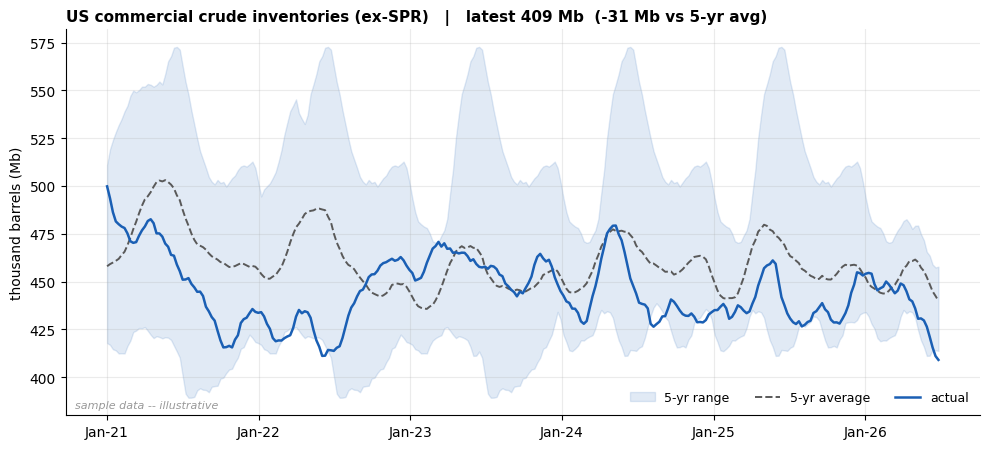

In [11]:
inv_chart(d["c_stk"], "US commercial crude inventories (ex-SPR)", "crude_inventories.png")

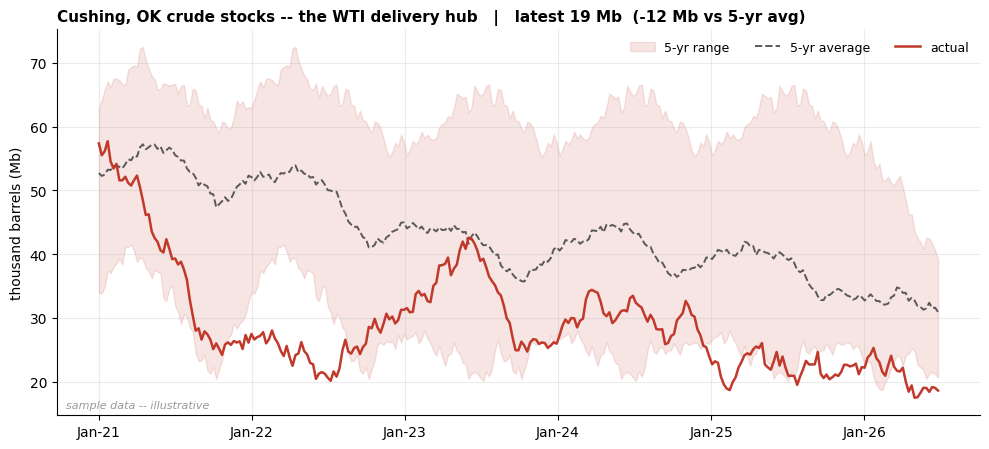

In [12]:
inv_chart(d["cush"], "Cushing, OK crude stocks -- the WTI delivery hub", "cushing.png",
          color="#c0392b")

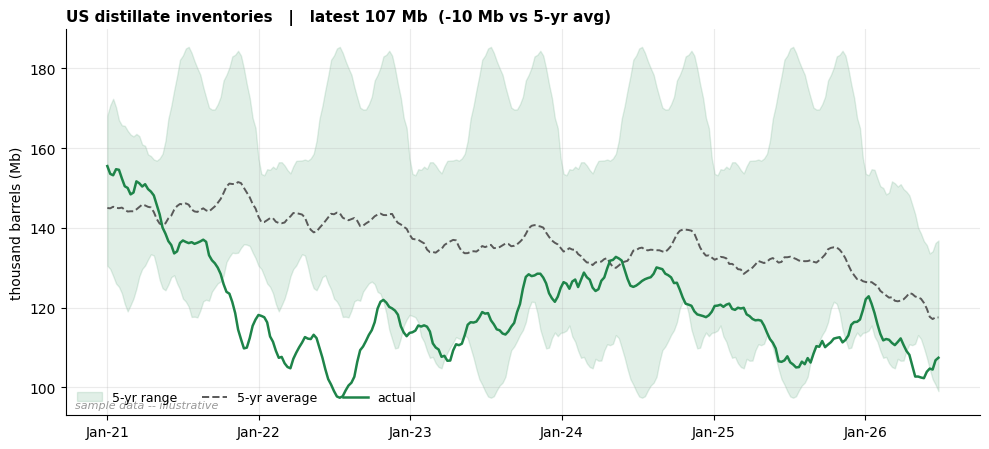

In [13]:
inv_chart(d["d_stk"], "US distillate inventories", "distillate_inventories.png",
          color="#1e8449")

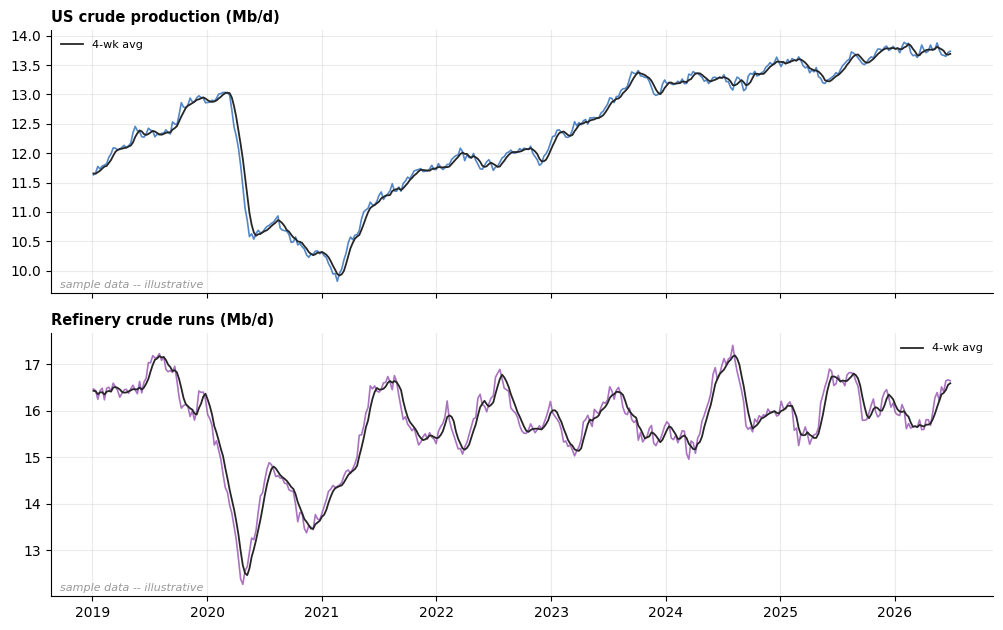

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True)
for ax, col, ttl, c in [(axes[0], "c_prod", "US crude production (Mb/d)", "#1a5fb4"),
                        (axes[1], "runs",   "Refinery crude runs (Mb/d)",  "#8e44ad")]:
    s = d[col][d.index >= "2019-01-01"]
    ax.plot(s.index, s, color=c, lw=1.2, alpha=0.75)
    ax.plot(s.index, d[col].rolling(4).mean().reindex(s.index), color="0.15", lw=1.3,
            label="4-wk avg")
    ax.set_title(ttl, loc="left", fontweight="bold", fontsize=10.5)
    ax.legend(frameon=False, fontsize=8)
    stamp(ax)
save_show(fig, "supply_side.png")

# Phase 2 · The balance sheet

Now the identity gets built explicitly, per commodity:

- **crude:** (field production + imports) − (refinery runs + exports)
- **distillate:** (refinery production + imports) − (product supplied + exports)

The weekly balance in Mb/d, multiplied by 7, gives the **implied** stock change; it is compared against the **actual** reported change. The gap between them is the *adjustment* — EIA's own reconciliation between surveyed flows and surveyed stock levels (the crude line was literally renamed from "unaccounted-for crude oil", and has run persistently positive since 2023). **It is a data-quality diagnostic, not a market signal.** When it blows out beyond its usual range, something in the inputs deserves a second look — that is where you dig.

In [15]:
# ── Phase 2: build the S/D balance sheet ─────────────────────────────────────
def build_balance(d):
    crude = pd.DataFrame({"supply_mbd": d.c_prod + d.c_imp,
                          "demand_mbd": d.runs + d.c_exp})
    dist = pd.DataFrame({"supply_mbd": d.d_prod + d.d_imp,
                         "demand_mbd": d.d_dem + d.d_exp})
    for b, stk in ((crude, d.c_stk), (dist, d.d_stk)):
        b["balance_mbd"]  = b.supply_mbd - b.demand_mbd
        b["implied_dstk"] = b.balance_mbd * 7.0        # Mb per week  (flows x 7)
        b["actual_dstk"]  = stk.diff()
        b["adjustment"]   = b.actual_dstk - b.implied_dstk   # EIA reconciliation proxy
    return crude, dist

bal_c, bal_d = build_balance(d)
print("Balance columns:", list(bal_c.columns))
print(f"Avg abs adjustment, last 52 wks -- crude: {bal_c.adjustment.tail(52).abs().mean():.1f} Mb/wk, "
      f"distillate: {bal_d.adjustment.tail(52).abs().mean():.1f} Mb/wk")

Balance columns: ['supply_mbd', 'demand_mbd', 'balance_mbd', 'implied_dstk', 'actual_dstk', 'adjustment']
Avg abs adjustment, last 52 wks -- crude: 3.6 Mb/wk, distillate: 1.3 Mb/wk


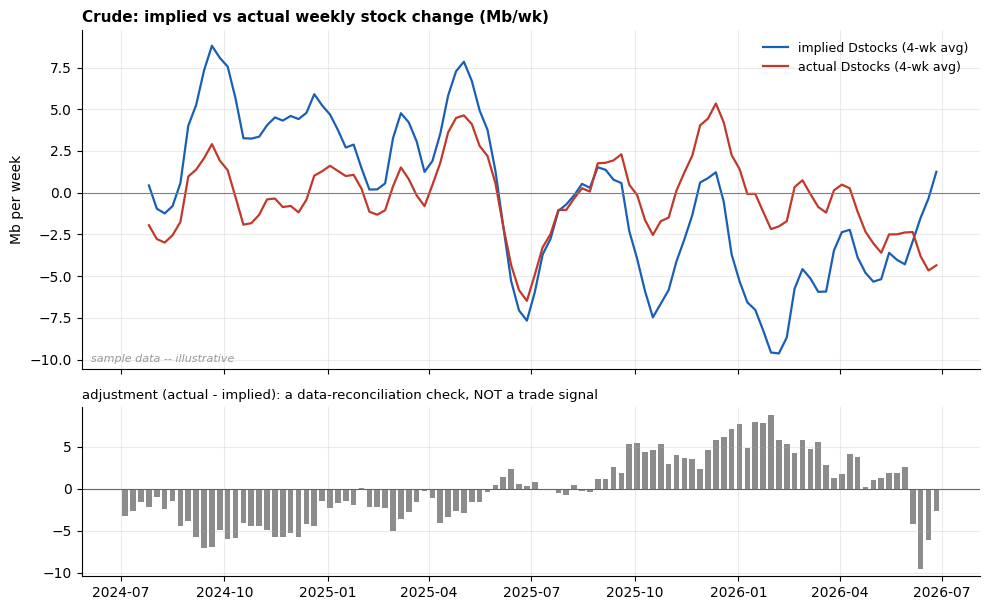

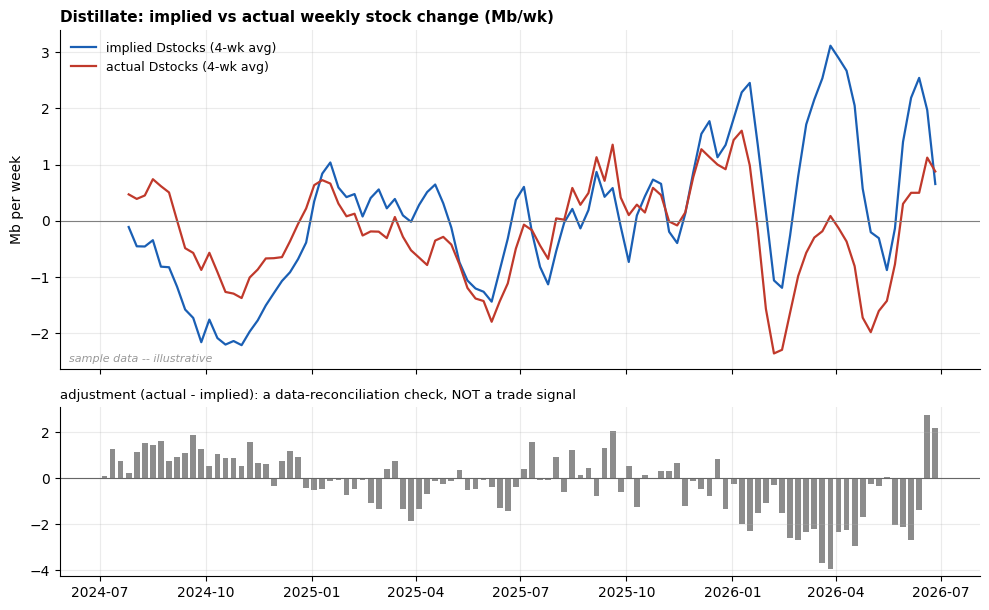

In [16]:
def balance_chart(b, name, fname):
    w = b[b.index >= "2024-07-01"]
    fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(w.index, w.implied_dstk.rolling(4).mean(), color="#1a5fb4", lw=1.6,
                 label="implied Dstocks (4-wk avg)")
    axes[0].plot(w.index, w.actual_dstk.rolling(4).mean(), color="#c0392b", lw=1.6,
                 label="actual Dstocks (4-wk avg)")
    axes[0].axhline(0, color="0.5", lw=0.8)
    axes[0].set_title(f"{name}: implied vs actual weekly stock change (Mb/wk)",
                      loc="left", fontweight="bold", fontsize=11)
    axes[0].set_ylabel("Mb per week")
    axes[0].legend(frameon=False, fontsize=9)
    axes[1].bar(w.index, w.adjustment, width=5, color="0.55")
    axes[1].axhline(0, color="0.4", lw=0.8)
    axes[1].set_title("adjustment (actual - implied): a data-reconciliation check, NOT a trade signal",
                      loc="left", fontsize=9.5)
    stamp(axes[0])
    save_show(fig, fname)

balance_chart(bal_c, "Crude", "balance_crude.png")
balance_chart(bal_d, "Distillate", "balance_distillate.png")

In [17]:
def latest_balance_table(d, bal_c, bal_d):
    i = d.index[-1]
    rows = {
        ("supply",  "Production"):                       (d.c_prod.loc[i], d.d_prod.loc[i]),
        ("supply",  "+ Imports"):                        (d.c_imp.loc[i],  d.d_imp.loc[i]),
        ("supply",  "= Total supply (Mb/d)"):            (bal_c.supply_mbd.loc[i], bal_d.supply_mbd.loc[i]),
        ("demand",  "Refinery runs / Product supplied"): (d.runs.loc[i],   d.d_dem.loc[i]),
        ("demand",  "+ Exports"):                        (d.c_exp.loc[i],  d.d_exp.loc[i]),
        ("demand",  "= Total demand (Mb/d)"):            (bal_c.demand_mbd.loc[i], bal_d.demand_mbd.loc[i]),
        ("balance", "Net balance (Mb/d)"):               (bal_c.balance_mbd.loc[i], bal_d.balance_mbd.loc[i]),
        ("balance", "Implied Dstocks (Mb/wk)"):          (bal_c.implied_dstk.loc[i], bal_d.implied_dstk.loc[i]),
        ("balance", "Actual Dstocks (Mb/wk)"):           (bal_c.actual_dstk.loc[i],  bal_d.actual_dstk.loc[i]),
        ("balance", "Adjustment (Mb/wk)"):               (bal_c.adjustment.loc[i],   bal_d.adjustment.loc[i]),
    }
    t = pd.DataFrame(rows, index=["crude", "distillate"]).T
    print(f"Weekly balance sheet -- week ending {i.date()}")
    return t.round(2)

latest_balance_table(d, bal_c, bal_d)

Weekly balance sheet -- week ending 2026-06-26


crude  distillate
supply  Production                        13.73        5.48
        + Imports                          5.99        0.02
        = Total supply (Mb/d)             19.72        5.50
demand  Refinery runs / Product supplied  16.65        4.03
        + Exports                          2.98        1.69
        = Total demand (Mb/d)             19.63        5.72
balance Net balance (Mb/d)                 0.09       -0.22
        Implied Dstocks (Mb/wk)            0.60       -1.55
        Actual Dstocks (Mb/wk)            -2.01        0.63
        Adjustment (Mb/wk)                -2.61        2.18

# Phase 3 · Seasonal analysis — the core output

This is the number a desk actually trades off: **how many barrels above or below normal, and which way is it moving?** The deviation series below is the model's central signal; the snapshot table condenses the entire market state into three rows.

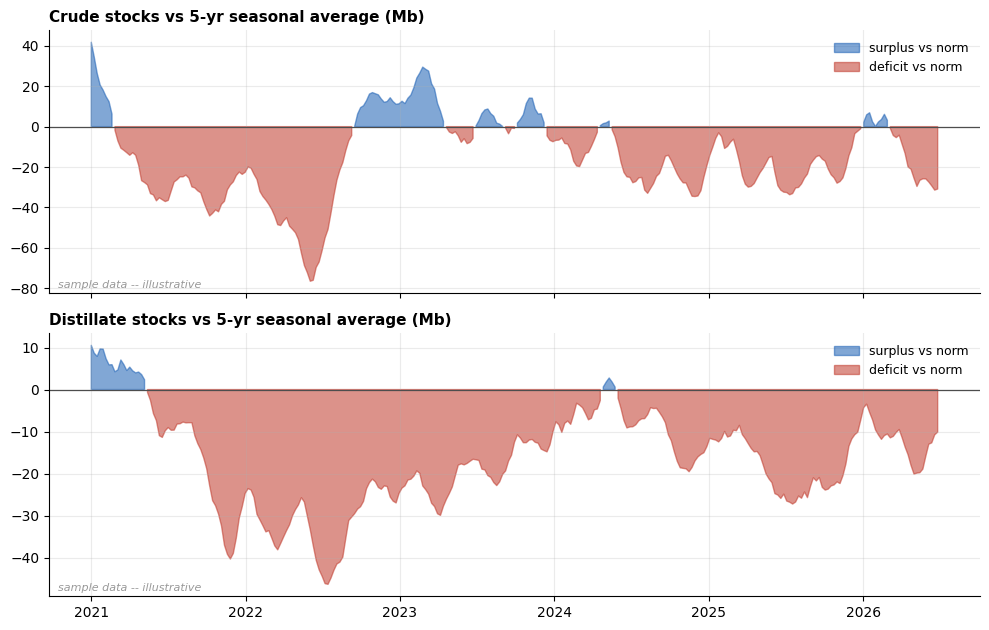

In [18]:
# ── Phase 3: inventory deviation vs the 5-yr seasonal norm (the core signal) ─
def deviation(s):
    avg, lo, hi = seasonal_series(s)
    dev = s - avg
    return dev, dev / avg * 100.0, (s - lo) / (hi - lo)

c_dev, c_devpct, c_pos = deviation(d.c_stk)
u_dev, u_devpct, u_pos = deviation(d.cush)
t_dev, t_devpct, t_pos = deviation(d.d_stk)

fig, axes = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True)
for ax, dev, ttl in [(axes[0], c_dev, "Crude stocks vs 5-yr seasonal average (Mb)"),
                     (axes[1], t_dev, "Distillate stocks vs 5-yr seasonal average (Mb)")]:
    w = dev[dev.index >= "2021-01-01"]
    ax.fill_between(w.index, 0, w.to_numpy(), where=(w >= 0).to_numpy(),
                    color="#1a5fb4", alpha=0.55, label="surplus vs norm")
    ax.fill_between(w.index, 0, w.to_numpy(), where=(w < 0).to_numpy(),
                    color="#c0392b", alpha=0.55, label="deficit vs norm")
    ax.axhline(0, color="0.3", lw=0.9)
    ax.set_title(ttl, loc="left", fontweight="bold", fontsize=11)
    ax.legend(frameon=False, fontsize=9, loc="best")
    stamp(ax)
save_show(fig, "seasonal_deviation.png")

In [19]:
def snapshot(d):
    out = {}
    for label, s, dev, devpct, pos in [
            ("Crude (comm., ex-SPR)", d.c_stk, c_dev, c_devpct, c_pos),
            ("Cushing",               d.cush,  u_dev, u_devpct, u_pos),
            ("Distillate",            d.d_stk, t_dev, t_devpct, t_pos)]:
        out[label] = {
            "level (Mb)":           float(s.iloc[-1]),
            "5-yr avg (Mb)":        float(s.iloc[-1] - dev.iloc[-1]),
            "vs 5-yr avg (Mb)":     float(dev.iloc[-1]),
            "vs 5-yr avg (%)":      float(devpct.iloc[-1]),
            "pos in 5-yr range":    float(pos.iloc[-1]),   # <0 means BELOW the 5-yr low
            "WoW D (Mb)":           float(s.diff().iloc[-1]),
            "4-wk D (Mb)":          float(s.iloc[-1] - s.iloc[-5]),
            "vs yr-ago (Mb)":       float(s.iloc[-1] - s.iloc[-53]),
        }
    return pd.DataFrame(out).T

snap = snapshot(d)
print(f"Inventory snapshot -- week ending {d.index[-1].date()}")
snap.round(2)

Inventory snapshot -- week ending 2026-06-26


,level (Mb),5-yr avg (Mb),vs 5-yr avg (Mb),vs 5-yr avg (%),pos in 5-yr range,WoW D (Mb),4-wk D (Mb),vs yr-ago (Mb)
"Crude (comm., ex-SPR)",409.00,439.91,-30.91,-7.03,-0.11,-2.01,-17.40,-24.33
Cushing,18.63,30.94,-12.31,-39.78,-0.11,-0.42,-0.41,-3.63
Distillate,107.40,117.52,-10.12,-8.61,0.22,0.63,3.51,-0.36


# Phase 4 · Forward projection

The baseline method is deliberately transparent: each flow follows its **5-year seasonal path**, plus the current 4-week deviation from that path **decaying at 0.85 per week** (momentum fades back toward normal). Implied weekly changes are integrated forward from the last actual level, carrying the recent average adjustment; the uncertainty band grows with √h using the historical dispersion of weekly stock-change surprises. Simple and fully explainable — every assumption is visible, which is the point in an interview.

In [20]:
# ── Phase 4: forward projection engine ───────────────────────────────────────
FLOWS = ["c_prod", "c_imp", "c_exp", "runs", "d_prod", "d_imp", "d_exp", "d_dem"]

def forecast_flows(d, horizon=HORIZON_WEEKS, decay=0.85):
    """Baseline flow forecast: the 5-yr seasonal path, plus the current 4-week
    deviation from that path fading out at `decay` per week (momentum -> normal)."""
    fut = pd.date_range(d.index[-1] + pd.Timedelta(weeks=1), periods=horizon, freq="W-FRI")
    fc = pd.DataFrame(index=fut)
    for c in FLOWS:
        sea_fut, _, _ = seasonal_series(d[c], fut)
        sea_now, _, _ = seasonal_series(d[c], d.index[-4:])
        dev = float(d[c].iloc[-4:].mean() - sea_now.mean())
        fc[c] = sea_fut.to_numpy() + dev * (decay ** np.arange(1, horizon + 1))
    return fc

def project(d, fc, adj_carry=True):
    """Integrate implied weekly changes forward from the last actual level.
    The recent average adjustment is carried (crude's is persistently positive)."""
    adj_c = float(bal_c.adjustment.tail(8).mean()) if adj_carry else 0.0
    adj_t = float(bal_d.adjustment.tail(8).mean()) if adj_carry else 0.0
    imp_c = (fc.c_prod + fc.c_imp - fc.runs - fc.c_exp) * 7.0 + adj_c
    imp_t = (fc.d_prod + fc.d_imp - fc.d_dem - fc.d_exp) * 7.0 + adj_t
    path_c = float(d.c_stk.iloc[-1]) + imp_c.cumsum()
    path_t = float(d.d_stk.iloc[-1]) + imp_t.cumsum()
    # uncertainty band: sd of weekly stock-change surprises, growing with sqrt(h)
    sd_c = float((d.c_stk.diff() - seasonal_series(d.c_stk.diff())[0]).tail(156).std())
    sd_t = float((d.d_stk.diff() - seasonal_series(d.d_stk.diff())[0]).tail(156).std())
    h = np.sqrt(np.arange(1, len(fc) + 1))
    return dict(fut=fc.index, crude=path_c, dist=path_t,
                band_c=1.28 * sd_c * h, band_t=1.28 * sd_t * h, flows=fc)

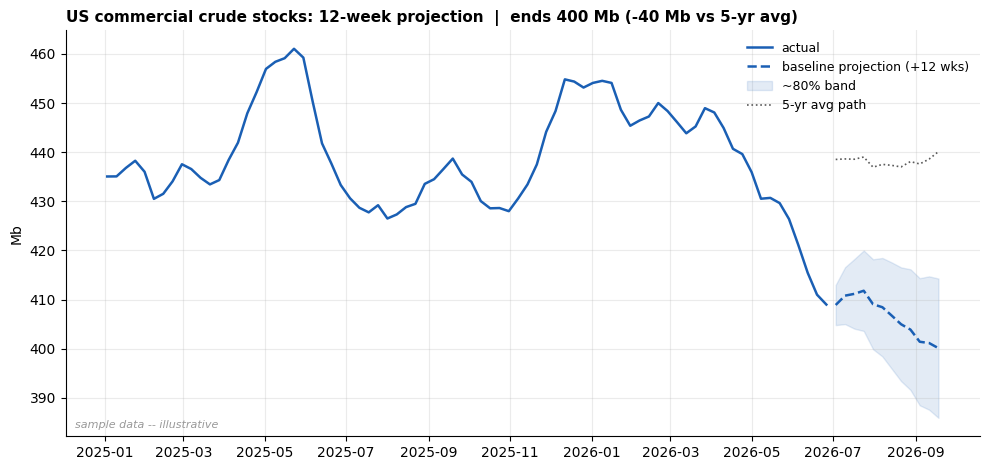

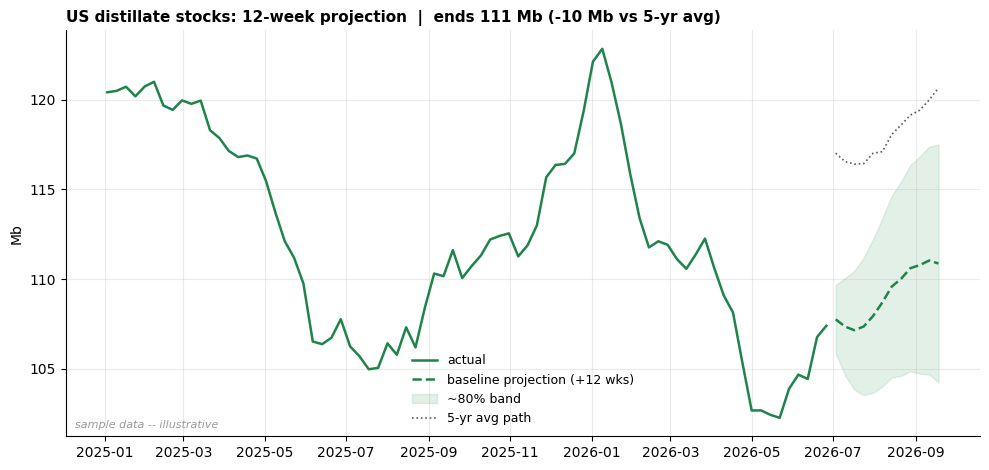

In [21]:
fc_base = forecast_flows(d)
proj = project(d, fc_base)

def projection_chart(hist, path, band, name, color, fname):
    avg_f, _, _ = seasonal_series(hist, path.index)
    w = hist[hist.index >= "2025-01-01"]
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(w.index, w, color=color, lw=1.8, label="actual")
    ax.plot(path.index, path, color=color, lw=1.8, ls="--",
            label=f"baseline projection (+{len(path)} wks)")
    ax.fill_between(path.index, (path - band).to_numpy(), (path + band).to_numpy(),
                    color=color, alpha=0.12, label="~80% band")
    ax.plot(path.index, avg_f, color="0.35", lw=1.2, ls=":", label="5-yr avg path")
    enddev = float(path.iloc[-1] - avg_f.iloc[-1])
    ax.set_title(f"{name}: {len(path)}-week projection  |  ends {path.iloc[-1]:,.0f} Mb "
                 f"({enddev:+,.0f} Mb vs 5-yr avg)", loc="left", fontweight="bold", fontsize=11)
    ax.set_ylabel("Mb")
    ax.legend(frameon=False, fontsize=9, loc="best")
    stamp(ax)
    save_show(fig, fname)
    return enddev

end_dev_c = projection_chart(d.c_stk, proj["crude"], proj["band_c"],
                             "US commercial crude stocks", "#1a5fb4", "projection_crude.png")
end_dev_t = projection_chart(d.d_stk, proj["dist"], proj["band_t"],
                             "US distillate stocks", "#1e8449", "projection_distillate.png")

## What-if scenario tool

`run_scenario()` shocks any combination of flows for a chosen number of weeks, then reverts to baseline. A refinery-run shock automatically propagates to distillate output through the observed distillate yield (≈30% of crude runs) — cut runs and you *build* crude but *draw* diesel. The first example is the spec's: **refinery runs −5% for 4 weeks** (a hurricane / outage profile).

In [22]:
# ── What-if scenario tool ────────────────────────────────────────────────────
DIST_YIELD = float((d.d_prod / d.runs).tail(52).mean())   # distillate yield on runs (~0.30)

def run_scenario(d, label, weeks_shocked=4, runs_pct=0.0, c_prod_delta=0.0,
                 c_imp_delta=0.0, c_exp_delta=0.0, d_dem_pct=0.0, d_exp_delta=0.0,
                 horizon=HORIZON_WEEKS):
    """Apply shocks to the baseline flow forecast for the first `weeks_shocked`
    weeks, then revert. pct args are % changes; delta args are Mb/d add-ons.
    A refinery-run cut automatically cuts distillate output via DIST_YIELD."""
    base = forecast_flows(d, horizon)
    fc = base.copy()
    m = fc.index[np.arange(horizon) < weeks_shocked]
    d_runs = base.loc[m, "runs"] * (runs_pct / 100.0)
    fc.loc[m, "runs"]   = base.loc[m, "runs"] + d_runs
    fc.loc[m, "d_prod"] = base.loc[m, "d_prod"] + d_runs * DIST_YIELD
    fc.loc[m, "c_prod"] = base.loc[m, "c_prod"] + c_prod_delta
    fc.loc[m, "c_imp"]  = base.loc[m, "c_imp"]  + c_imp_delta
    fc.loc[m, "c_exp"]  = base.loc[m, "c_exp"]  + c_exp_delta
    fc.loc[m, "d_dem"]  = base.loc[m, "d_dem"] * (1 + d_dem_pct / 100.0)
    fc.loc[m, "d_exp"]  = base.loc[m, "d_exp"]  + d_exp_delta
    return dict(label=label, base=project(d, base), scen=project(d, fc))

def scenario_report(sc):
    bl, sn = sc["base"], sc["scen"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, key, name, color, hist in [(axes[0], "crude", "Crude stocks", "#1a5fb4", d.c_stk),
                                       (axes[1], "dist", "Distillate stocks", "#1e8449", d.d_stk)]:
        w = hist[hist.index >= "2026-01-01"]
        ax.plot(w.index, w, color="0.4", lw=1.3, label="actual")
        ax.plot(bl["fut"], bl[key], color=color, lw=1.6, ls="--", label="baseline")
        ax.plot(sn["fut"], sn[key], color="#c0392b", lw=1.8, label=sc["label"])
        ax.set_title(name, loc="left", fontweight="bold", fontsize=10.5)
        ax.legend(frameon=False, fontsize=8)
        stamp(ax)
    save_show(fig, f"scenario_{sc['label'].replace(' ', '_').replace('%','pct')}.png")
    t = pd.DataFrame({
        "baseline end (Mb)":  [float(bl["crude"].iloc[-1]), float(bl["dist"].iloc[-1])],
        "scenario end (Mb)":  [float(sn["crude"].iloc[-1]), float(sn["dist"].iloc[-1])],
    }, index=["crude", "distillate"])
    t["impact vs baseline (Mb)"] = t["scenario end (Mb)"] - t["baseline end (Mb)"]
    print(f"Scenario: {sc['label']}  --  end-of-horizon inventories ({HORIZON_WEEKS} wks out)")
    return t.round(1)

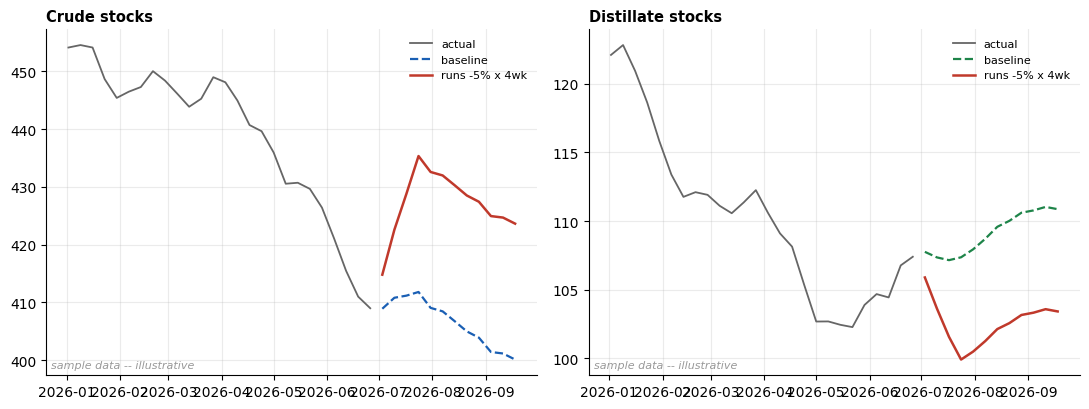

Scenario: runs -5% x 4wk  --  end-of-horizon inventories (12 wks out)


,baseline end (Mb),scenario end (Mb),impact vs baseline (Mb)
crude,400.10,423.60,23.50
distillate,110.90,103.40,-7.50


In [23]:
# The spec's example: refinery runs drop 5% for 4 weeks (hurricane / outage).
sc1 = run_scenario(d, "runs -5% x 4wk", weeks_shocked=4, runs_pct=-5.0)
scenario_report(sc1)

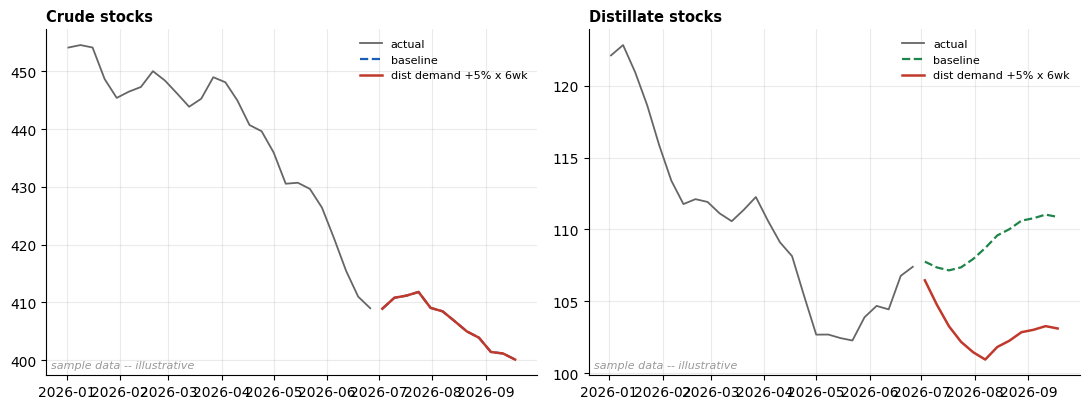

Scenario: dist demand +5% x 6wk  --  end-of-horizon inventories (12 wks out)


,baseline end (Mb),scenario end (Mb),impact vs baseline (Mb)
crude,400.10,400.10,0.00
distillate,110.90,103.10,-7.80


In [24]:
# A second example: a cold-snap style distillate demand pop, +5% for 6 weeks.
sc2 = run_scenario(d, "dist demand +5% x 6wk", weeks_shocked=6, d_dem_pct=5.0)
scenario_report(sc2)

# Phase 5 · The market view

Everything above collapses into an explicit, plain-English view — tight or loose, versus normal, and heading which way — plus a one-page PDF (`weekly_market_view.pdf`) regenerated on every run: the artifact you hand a manager or carry into an interview.

In [25]:
# ── Phase 5: turn the numbers into an explicit market view ───────────────────
def classify(devpct):
    return "TIGHT" if devpct < -4 else ("LOOSE" if devpct > 4 else "BALANCED")

def range_phrase(pos):
    if pos < 0:    return "below the bottom of its 5-yr range"
    if pos < 0.25: return "in the bottom quartile of its 5-yr range"
    if pos > 1:    return "above the top of its 5-yr range"
    if pos > 0.75: return "in the top quartile of its 5-yr range"
    return "inside its 5-yr range"

def market_view(d, snap, proj):
    i = d.index[-1]
    avg_cf, _, _ = seasonal_series(d.c_stk, proj["fut"])
    avg_tf, _, _ = seasonal_series(d.d_stk, proj["fut"])
    ec = float(proj["crude"].iloc[-1] - avg_cf.iloc[-1])   # end-horizon dev vs 5-yr avg
    et = float(proj["dist"].iloc[-1]  - avg_tf.iloc[-1])
    c, u, t = (snap.loc["Crude (comm., ex-SPR)"], snap.loc["Cushing"], snap.loc["Distillate"])
    horizon_end = proj["fut"][-1].date()

    trend = lambda now, end: (("widening" if abs(end) > abs(now) else "narrowing")
                              if end * now >= 0 else "flipping sign")
    mv = {}
    mv["asof"] = str(i.date())
    mv["crude_class"], mv["dist_class"] = classify(c["vs 5-yr avg (%)"]), classify(t["vs 5-yr avg (%)"])
    mv["crude_para"] = (
        f"Commercial crude stocks are {c['level (Mb)']:,.0f} Mb, {abs(c['vs 5-yr avg (Mb)']):,.0f} Mb "
        f"({abs(c['vs 5-yr avg (%)']):.0f}%) {'below' if c['vs 5-yr avg (Mb)'] < 0 else 'above'} the 5-yr "
        f"seasonal average and {range_phrase(c['pos in 5-yr range'])}. The last 4 weeks "
        f"{'drew' if c['4-wk D (Mb)'] < 0 else 'built'} {abs(c['4-wk D (Mb)']):,.0f} Mb. The baseline "
        f"projection has the deficit at {abs(ec):,.0f} Mb by {horizon_end} "
        f"({trend(c['vs 5-yr avg (Mb)'], ec)})." if c['vs 5-yr avg (Mb)'] < 0 else
        f"Commercial crude stocks are {c['level (Mb)']:,.0f} Mb, {c['vs 5-yr avg (Mb)']:,.0f} Mb above "
        f"the 5-yr average; projected {ec:+,.0f} Mb vs norm by {horizon_end}.")
    mv["cushing_line"] = (
        f"Cushing sits at {u['level (Mb)']:,.1f} Mb, {range_phrase(u['pos in 5-yr range'])} "
        f"({u['vs 5-yr avg (%)']:+.0f}% vs 5-yr avg) -- the WTI delivery point is "
        f"{'critically thin' if u['pos in 5-yr range'] < 0.1 else 'adequately supplied'}.")
    mv["dist_para"] = (
        f"Distillate stocks are {t['level (Mb)']:,.0f} Mb, {abs(t['vs 5-yr avg (Mb)']):,.0f} Mb "
        f"({abs(t['vs 5-yr avg (%)']):.0f}%) {'below' if t['vs 5-yr avg (Mb)'] < 0 else 'above'} the "
        f"5-yr average, {range_phrase(t['pos in 5-yr range'])}. 4-wk change: "
        f"{t['4-wk D (Mb)']:+,.0f} Mb. Baseline projection puts the gap at {et:+,.0f} Mb vs norm "
        f"by {horizon_end}, i.e. {'still well short of' if et < -4 else 'converging toward'} "
        f"normal ahead of the winter heating season.")
    bias_c = ("supportive of flat price and backwardated WTI structure" if mv["crude_class"] == "TIGHT"
              else "pressuring flat price and WTI structure" if mv["crude_class"] == "LOOSE"
              else "neutral for WTI structure")
    bias_t = ("constructive for diesel cracks and HO spreads" if mv["dist_class"] == "TIGHT"
              else "bearish diesel cracks" if mv["dist_class"] == "LOOSE"
              else "neutral for diesel cracks")
    mv["view_line"] = (f"MODEL VIEW: crude {mv['crude_class']} ({bias_c}); "
                       f"distillate {mv['dist_class']} ({bias_t}).")
    mv["caveat"] = ("Generated from SYNTHETIC sample data -- illustrative output only. "
                    "Connect a live EIA API key for the real current view."
                    if DATA_MODE.startswith("SAMPLE") else
                    "Generated from live EIA weekly data.")
    return mv

MV = market_view(d, snap, proj)
VIEW_TEXT = "\n\n".join([
    f"US CRUDE & DISTILLATE -- WEEKLY S/D VIEW   (week ending {MV['asof']})",
    MV["crude_para"], MV["cushing_line"], MV["dist_para"], MV["view_line"], MV["caveat"]])
print(VIEW_TEXT)

US CRUDE & DISTILLATE -- WEEKLY S/D VIEW   (week ending 2026-06-26)

Commercial crude stocks are 409 Mb, 31 Mb (7%) below the 5-yr seasonal average and below the bottom of its 5-yr range. The last 4 weeks drew 17 Mb. The baseline projection has the deficit at 40 Mb by 2026-09-18 (widening).

Cushing sits at 18.6 Mb, below the bottom of its 5-yr range (-40% vs 5-yr avg) -- the WTI delivery point is critically thin.

Distillate stocks are 107 Mb, 10 Mb (9%) below the 5-yr average, in the bottom quartile of its 5-yr range. 4-wk change: +4 Mb. Baseline projection puts the gap at -10 Mb vs norm by 2026-09-18, i.e. still well short of normal ahead of the winter heating season.

MODEL VIEW: crude TIGHT (supportive of flat price and backwardated WTI structure); distillate TIGHT (constructive for diesel cracks and HO spreads).

Generated from SYNTHETIC sample data -- illustrative output only. Connect a live EIA API key for the real current view.


In [26]:
# ── The one-page weekly summary (PDF) -- the interview / manager artifact ────
def build_onepager(path=ONEPAGER):
    from reportlab.lib.pagesizes import letter
    from reportlab.lib.units import inch
    from reportlab.lib import colors
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Image,
                                    Table, TableStyle)
    from PIL import Image as PILImage

    styles = getSampleStyleSheet()
    small = ParagraphStyle("small", parent=styles["Normal"], fontSize=8.6, leading=11.6)
    h1 = ParagraphStyle("h1", parent=styles["Title"], fontSize=15, spaceAfter=2)
    sub = ParagraphStyle("sub", parent=styles["Normal"], fontSize=9, textColor=colors.grey)
    hd = ParagraphStyle("hd", parent=styles["Heading4"], fontSize=9.5, spaceBefore=6, spaceAfter=2)

    def img(fname, w_in):
        p = CHART_DIR / fname
        iw, ih = PILImage.open(p).size
        return Image(str(p), width=w_in * inch, height=w_in * inch * ih / iw)

    tbl = snap.round(1).reset_index().rename(columns={"index": ""})
    data = [list(tbl.columns)] + tbl.values.tolist()
    t = Table(data, hAlign="LEFT")
    t.setStyle(TableStyle([
        ("FONT", (0, 0), (-1, -1), "Helvetica", 7.4),
        ("FONT", (0, 0), (-1, 0), "Helvetica-Bold", 7.4),
        ("LINEBELOW", (0, 0), (-1, 0), 0.6, colors.black),
        ("LINEBELOW", (0, -1), (-1, -1), 0.4, colors.grey),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.Color(0.96, 0.96, 0.96)]),
        ("TOPPADDING", (0, 0), (-1, -1), 1.6), ("BOTTOMPADDING", (0, 0), (-1, -1), 1.6),
    ]))

    doc = SimpleDocTemplate(str(path), pagesize=letter, topMargin=0.5 * inch,
                            bottomMargin=0.45 * inch, leftMargin=0.55 * inch,
                            rightMargin=0.55 * inch)
    story = [
        Paragraph("US Crude &amp; Distillate -- Weekly S/D Monitor", h1),
        Paragraph(f"Week ending {MV['asof']} &nbsp;|&nbsp; EIA Weekly Petroleum Status Report "
                  f"&nbsp;|&nbsp; {MV['caveat']}", sub),
        Spacer(1, 6),
        Paragraph("Inventory snapshot vs 5-year seasonal norm", hd), t, Spacer(1, 5),
        Table([[img("crude_inventories.png", 3.55), img("distillate_inventories.png", 3.55)]],
              hAlign="LEFT"),
        Paragraph("Crude", hd), Paragraph(MV["crude_para"], small),
        Paragraph(MV["cushing_line"], small),
        Paragraph("Distillate", hd), Paragraph(MV["dist_para"], small),
        Paragraph("View", hd),
        Paragraph(f"<b>{MV['view_line']}</b>", small), Spacer(1, 4),
        Paragraph(f"Method: weekly EIA balance (Supply - Demand = DInventory), inventory level vs "
                  f"trailing 5-yr seasonal average, {HORIZON_WEEKS}-week flow-based projection. "
                  f"Balance residual is tracked as a data-quality check only.", sub),
    ]
    doc.build(story)
    print(f"One-pager written -> {path}")

try:
    build_onepager()
except ImportError as e:
    print(f"reportlab/Pillow not installed ({e}) -- run: pip install reportlab pillow")

One-pager written -> weekly_market_view.pdf


## Appendix

**Data traps this model deliberately avoids**

- *gross vs net imports* — both flows kept gross, on opposite sides of the balance
- *SPR-inclusive stocks* — `WCESTUS1` is commercial-only; SPR releases are policy noise
- *refinery inputs vs utilization* — the model uses the Mb/d volume, not the %
- *product supplied* — a demand proxy, and it sits on the demand side, never supply
- *regional detail* — PADD sub-components don't stack cleanly onto national totals; regional balances are a later phase
- *Mb vs Mb/d* — every flow-to-stock conversion multiplies by 7, and units are documented per column

**Weekly workflow** — Wednesday 10:30am ET release → *Run All* → read the QA block → check the deviation chart and snapshot table → skim the adjustment line → send the regenerated one-pager.

**Roadmap** — PADD-level regional balances (PADD 1 distillate vs NY Harbor pricing, PADD 3 export capacity), gasoline as a third commodity, and cross-checking EIA export prints against vessel-tracking data of the kind desks use (Kpler / Vortexa).